<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/Taller_1_OCTUBRE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TALLER EN CLASES

#HAMERSON JOEL PIARPUEZAN PIARPUEZAN

#Codigo para extraer los datos del archivo

In [5]:
import pandas as pd

# Replace 'your_database.csv' with the actual path to your database file
try:
    df = pd.read_csv('weather_features.csv')
    print("Database loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: The file 'weather_features.csv' was not found. Please provide the correct path to your database file.")
except Exception as e:
    print(f"An error occurred: {e}")

Database loaded successfully!


/tmp/ipython-input-3037941425.py:5: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('weather_features.csv')


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


#Codigo para extraer los datos de interes, HUMEDAD

In [8]:
# Extract the 'humidity' column
humidity_data = df['humidity']

# Display the humidity data
display(humidity_data)

,humidity
0,77
1,77
2,78
3,78
4,78
...,...
356788,54
356789,62
356790,58
356791,57


#Codigo para graficar los metodos de la PSD, PERIODOGRAM, WELCH, MULTITAPER. con los datos de HUMEDAD

Total de muestras: 356793
Frecuencia de muestreo: 1.0 Hz

MÉTODO 1: PERIODOGRAM
Frecuencias calculadas: 178397
Rango de frecuencias: 0.000000 - 0.499999 Hz
Potencia máxima: 9.4248e+06

MÉTODO 2: WELCH
Segmentos de: 256 puntos
Frecuencias calculadas: 129
Rango de frecuencias: 0.000000 - 0.500000 Hz
Potencia máxima: 1.6461e+04

MÉTODO 3: MULTITAPER (aproximación)
Número de tapers: 5
Frecuencias calculadas: 178397
Rango de frecuencias: 0.000000 - 0.499999 Hz
Potencia máxima: 1.0635e+07

GENERANDO GRÁFICAS...


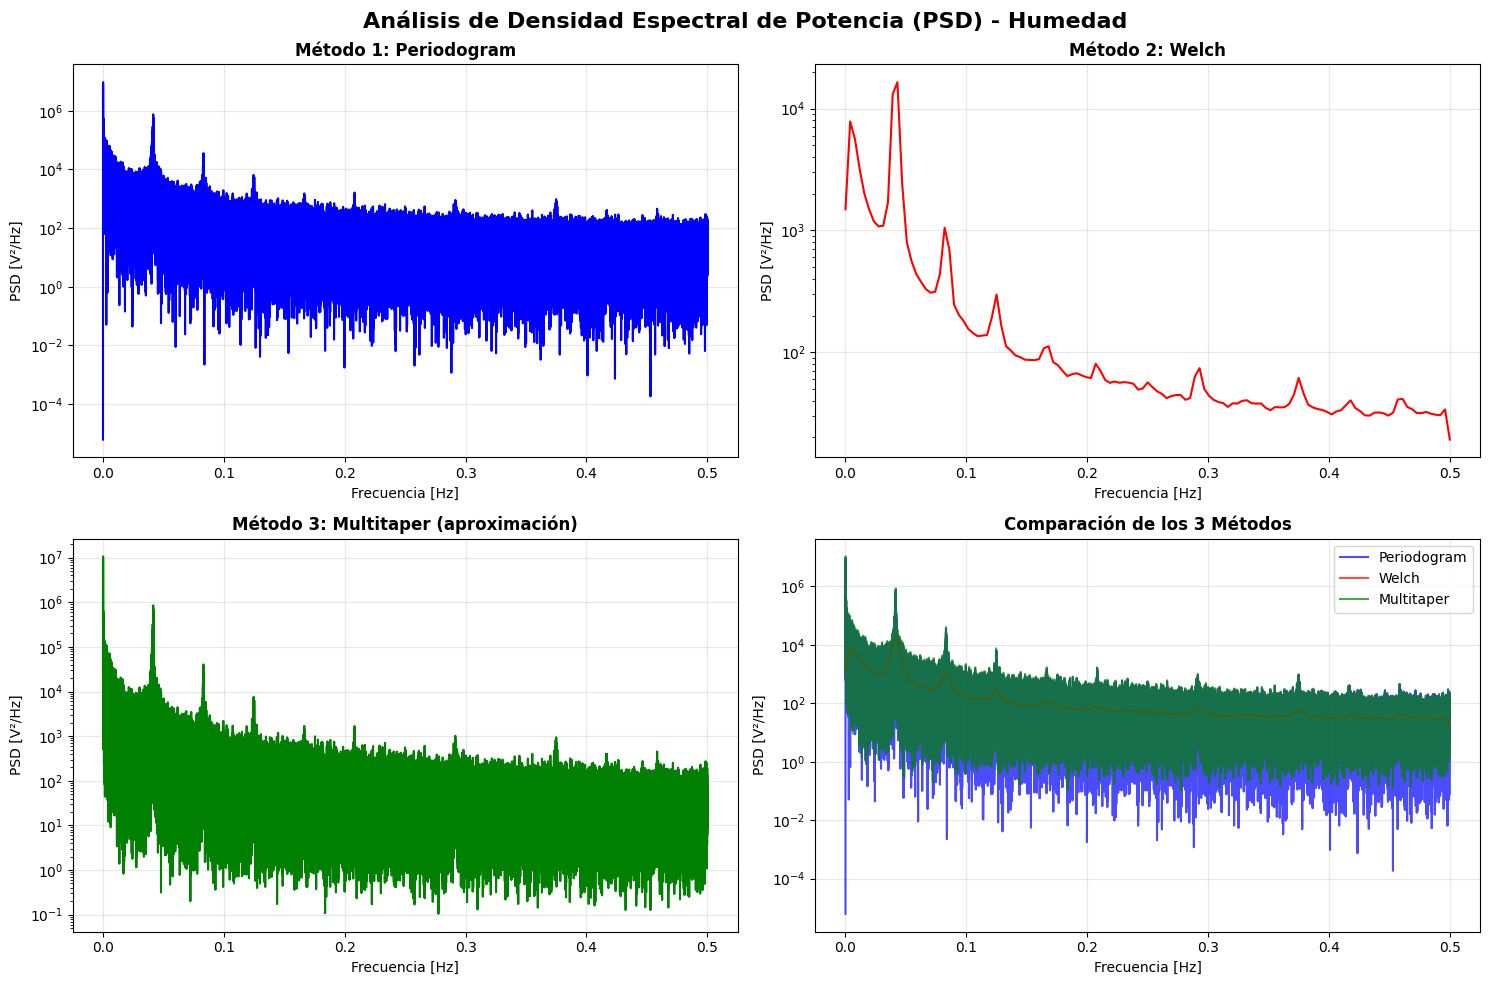


GUARDANDO RESULTADOS...
✓ Resultados guardados en 'psd_results.csv'

¡Análisis completado exitosamente!


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import welch, periodogram

# Ya tienes tus datos de humedad cargados
# humidity_data = df['humidity']

# Convertir a array numpy y eliminar valores NaN
humidity = humidity_data.dropna().values

# Frecuencia de muestreo (ajusta según tu dataset)
# Si tus datos son horarios, fs=1/3600, si son diarios fs=1/86400, etc.
fs = 1.0  # Asume 1 muestra por unidad de tiempo (ajusta según tu caso)

print(f"Total de muestras: {len(humidity)}")
print(f"Frecuencia de muestreo: {fs} Hz\n")

# =============================================================================
# MÉTODO 1: PERIODOGRAM
# =============================================================================
print("=" * 60)
print("MÉTODO 1: PERIODOGRAM")
print("=" * 60)

freq_per, psd_per = periodogram(humidity, fs=fs, window='hann', scaling='density')

print(f"Frecuencias calculadas: {len(freq_per)}")
print(f"Rango de frecuencias: {freq_per[0]:.6f} - {freq_per[-1]:.6f} Hz")
print(f"Potencia máxima: {np.max(psd_per):.4e}\n")

# =============================================================================
# MÉTODO 2: WELCH
# =============================================================================
print("=" * 60)
print("MÉTODO 2: WELCH")
print("=" * 60)

# nperseg: número de puntos por segmento (ajusta según tu dataset)
nperseg = min(256, len(humidity) // 4)
freq_welch, psd_welch = welch(humidity, fs=fs, nperseg=nperseg,
                               window='hann', scaling='density')

print(f"Segmentos de: {nperseg} puntos")
print(f"Frecuencias calculadas: {len(freq_welch)}")
print(f"Rango de frecuencias: {freq_welch[0]:.6f} - {freq_welch[-1]:.6f} Hz")
print(f"Potencia máxima: {np.max(psd_welch):.4e}\n")

# =============================================================================
# MÉTODO 3: MULTITAPER (usando scipy.signal.spectrogram con múltiples tapers)
# =============================================================================
print("=" * 60)
print("MÉTODO 3: MULTITAPER (aproximación)")
print("=" * 60)

# Nota: scipy no tiene implementación nativa de multitaper
# Aquí uso una aproximación promediando varios periodogramas con diferentes ventanas
# Para un verdadero multitaper, considera usar la librería 'nitime' o 'mne'

def multitaper_approx(data, fs, n_tapers=5):
    """Aproximación de multitaper promediando múltiples periodogramas"""
    windows = ['hann', 'hamming', 'blackman', 'bartlett', 'boxcar']
    psds = []

    for window in windows[:n_tapers]:
        freq, psd = periodogram(data, fs=fs, window=window, scaling='density')
        psds.append(psd)

    # Promediar todas las estimaciones
    psd_multi = np.mean(psds, axis=0)
    return freq, psd_multi

freq_multi, psd_multi = multitaper_approx(humidity, fs=fs, n_tapers=5)

print(f"Número de tapers: 5")
print(f"Frecuencias calculadas: {len(freq_multi)}")
print(f"Rango de frecuencias: {freq_multi[0]:.6f} - {freq_multi[-1]:.6f} Hz")
print(f"Potencia máxima: {np.max(psd_multi):.4e}\n")

# =============================================================================
# VISUALIZACIÓN COMPARATIVA
# =============================================================================
print("=" * 60)
print("GENERANDO GRÁFICAS...")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análisis de Densidad Espectral de Potencia (PSD) - Humedad',
             fontsize=16, fontweight='bold')

# Gráfica 1: Periodogram
axes[0, 0].semilogy(freq_per, psd_per, 'b-', linewidth=1.5)
axes[0, 0].set_title('Método 1: Periodogram', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Frecuencia [Hz]')
axes[0, 0].set_ylabel('PSD [V²/Hz]')
axes[0, 0].grid(True, alpha=0.3)

# Gráfica 2: Welch
axes[0, 1].semilogy(freq_welch, psd_welch, 'r-', linewidth=1.5)
axes[0, 1].set_title('Método 2: Welch', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Frecuencia [Hz]')
axes[0, 1].set_ylabel('PSD [V²/Hz]')
axes[0, 1].grid(True, alpha=0.3)

# Gráfica 3: Multitaper
axes[1, 0].semilogy(freq_multi, psd_multi, 'g-', linewidth=1.5)
axes[1, 0].set_title('Método 3: Multitaper (aproximación)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Frecuencia [Hz]')
axes[1, 0].set_ylabel('PSD [V²/Hz]')
axes[1, 0].grid(True, alpha=0.3)

# Gráfica 4: Comparación de los tres métodos
axes[1, 1].semilogy(freq_per, psd_per, 'b-', alpha=0.7, label='Periodogram', linewidth=1.5)
axes[1, 1].semilogy(freq_welch, psd_welch, 'r-', alpha=0.7, label='Welch', linewidth=1.5)
axes[1, 1].semilogy(freq_multi, psd_multi, 'g-', alpha=0.7, label='Multitaper', linewidth=1.5)
axes[1, 1].set_title('Comparación de los 3 Métodos', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Frecuencia [Hz]')
axes[1, 1].set_ylabel('PSD [V²/Hz]')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# GUARDAR RESULTADOS
# =============================================================================
print("\n" + "=" * 60)
print("GUARDANDO RESULTADOS...")
print("=" * 60)

results_df = pd.DataFrame({
    'Frequency_Periodogram': freq_per,
    'PSD_Periodogram': psd_per,
    'Frequency_Welch': np.pad(freq_welch, (0, len(freq_per) - len(freq_welch)),
                               constant_values=np.nan),
    'PSD_Welch': np.pad(psd_welch, (0, len(freq_per) - len(freq_welch)),
                        constant_values=np.nan),
    'Frequency_Multitaper': freq_multi,
    'PSD_Multitaper': psd_multi
})

results_df.to_csv('psd_results.csv', index=False)
print("✓ Resultados guardados en 'psd_results.csv'")
print("\n¡Análisis completado exitosamente!")

#Este codigo para saber cada cuanto tiempo se tomaron las muestras de HUMEDAD, en este caso cada hora por lo cual su Fs = 1/3600

In [30]:
# Ver las primeras filas con timestamp (si existe columna de fecha/hora)
display(df.head(10))

# O si tienes columna de tiempo:
# display(df[['timestamp', 'humidity']].head(10))

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
5,2015-01-01 05:00:00+01:00,Valencia,270.292,270.292,270.292,1004,71,2,321,0.0,0.0,0.0,0,800,clear,sky is clear,01n
6,2015-01-01 06:00:00+01:00,Valencia,270.292,270.292,270.292,1004,71,2,321,0.0,0.0,0.0,0,800,clear,sky is clear,01n
7,2015-01-01 07:00:00+01:00,Valencia,270.292,270.292,270.292,1004,71,2,321,0.0,0.0,0.0,0,800,clear,sky is clear,01n
8,2015-01-01 08:00:00+01:00,Valencia,274.601,274.601,274.601,1005,71,1,307,0.0,0.0,0.0,0,800,clear,sky is clear,01d
9,2015-01-01 09:00:00+01:00,Valencia,274.601,274.601,274.601,1005,71,1,307,0.0,0.0,0.0,0,800,clear,sky is clear,01d


#Comparacion tiempo de ejecucion, recursos consumidos.

Total de muestras: 356793
Frecuencia de muestreo: 0.0002777777777777778 Hz


MÉTODO: PERIODOGRAM
⏱️  Tiempo de ejecución: 0.894916 segundos
💾 Memoria actual: 4.0857 MB
📊 Memoria pico: 21.7812 MB
🖥️  CPU promedio: 5.00%
Frecuencias calculadas: 178397
Potencia máxima: 3.3929e+10

MÉTODO: WELCH
⏱️  Tiempo de ejecución: 0.434881 segundos
💾 Memoria actual: 0.0153 MB
📊 Memoria pico: 10.9856 MB
🖥️  CPU promedio: 0.00%
Frecuencias calculadas: 129
Potencia máxima: 5.9261e+07

MÉTODO: MULTITAPER
⏱️  Tiempo de ejecución: 5.177389 segundos
💾 Memoria actual: 2.7263 MB
📊 Memoria pico: 34.0340 MB
🖥️  CPU promedio: 0.00%
Frecuencias calculadas: 178397
Potencia máxima: 3.8287e+10

TABLA COMPARATIVA DE RENDIMIENTO
     Método  Tiempo (segundos)  Memoria Pico (MB)  Memoria Usada (MB)  CPU (%)
PERIODOGRAM           0.894916          21.781181            4.085693      5.0
      WELCH           0.434881          10.985573            0.015329      0.0
 MULTITAPER           5.177389          34.034048        

/tmp/ipython-input-2723824754.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipython-input-2723824754.py:243: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.savefig('psd_comparison_performance.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-2723824754.py:243: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  plt.savefig('psd_comparison_performance.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-2723824754.py:243: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  plt.savefig('psd_comparison_performance.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pyla

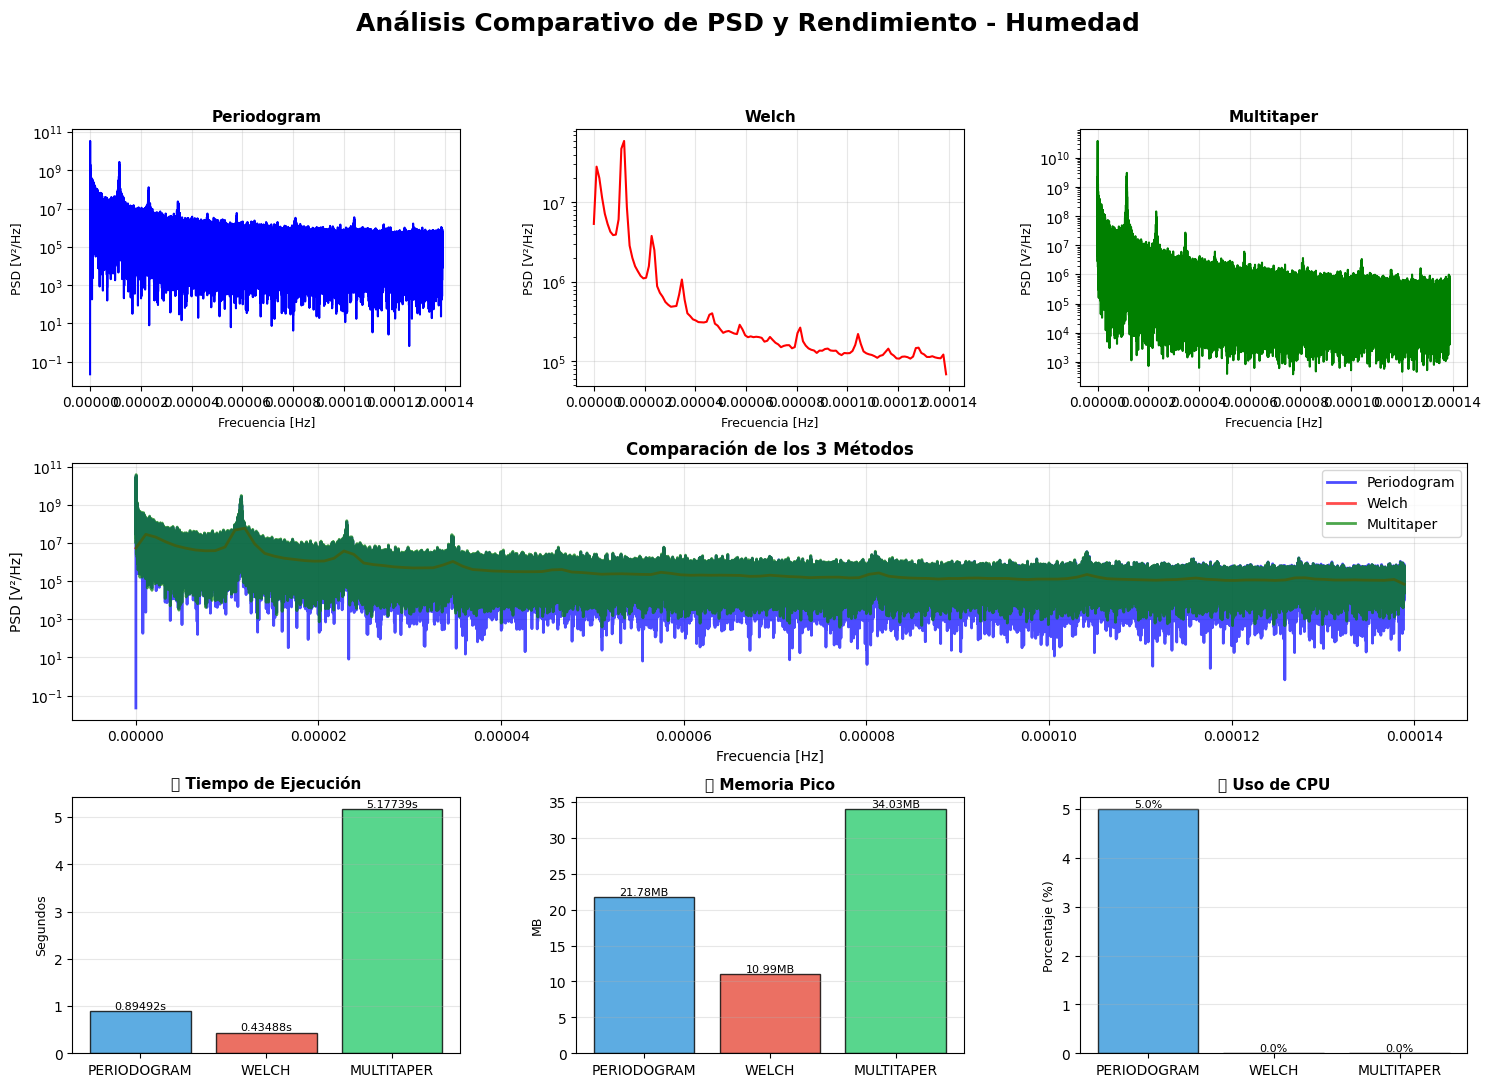


GUARDANDO RESULTADOS...
✓ Resultados PSD guardados en 'psd_results.csv'
✓ Métricas de rendimiento guardadas en 'performance_metrics.csv'

¡Análisis completado exitosamente! 🎉


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import welch, periodogram
import time
import tracemalloc
import psutil
import os

# Ya tienes tus datos de humedad cargados
# humidity_data = df['humidity']

# Convertir a array numpy y eliminar valores NaN
humidity = humidity_data.dropna().values

# Frecuencia de muestreo (ajusta según tu dataset)
#fs = 1.0  # Asume 1 muestra por unidad de tiempo (ajusta según tu caso)
fs = 1/3600
print(f"Total de muestras: {len(humidity)}")
print(f"Frecuencia de muestreo: {fs} Hz\n")

# Diccionario para almacenar métricas de rendimiento
metrics = {
    'Método': [],
    'Tiempo (segundos)': [],
    'Memoria Pico (MB)': [],
    'Memoria Usada (MB)': [],
    'CPU (%)': []
}

# Función auxiliar para medir recursos
def measure_performance(func, method_name, *args, **kwargs):
    """Mide tiempo, memoria y CPU de una función"""

    # Obtener proceso actual
    process = psutil.Process(os.getpid())

    # Iniciar medición de memoria
    tracemalloc.start()

    # CPU inicial
    cpu_percent_start = process.cpu_percent(interval=0.1)

    # Medir tiempo de ejecución
    start_time = time.time()
    result = func(*args, **kwargs)
    end_time = time.time()

    # CPU final
    cpu_percent_end = process.cpu_percent(interval=0.1)
    cpu_avg = (cpu_percent_start + cpu_percent_end) / 2

    # Memoria utilizada
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Calcular métricas
    execution_time = end_time - start_time
    memory_current_mb = current / 1024 / 1024
    memory_peak_mb = peak / 1024 / 1024

    # Guardar métricas
    metrics['Método'].append(method_name)
    metrics['Tiempo (segundos)'].append(execution_time)
    metrics['Memoria Pico (MB)'].append(memory_peak_mb)
    metrics['Memoria Usada (MB)'].append(memory_current_mb)
    metrics['CPU (%)'].append(cpu_avg)

    print(f"\n{'='*60}")
    print(f"MÉTODO: {method_name}")
    print(f"{'='*60}")
    print(f"⏱️  Tiempo de ejecución: {execution_time:.6f} segundos")
    print(f"💾 Memoria actual: {memory_current_mb:.4f} MB")
    print(f"📊 Memoria pico: {memory_peak_mb:.4f} MB")
    print(f"🖥️  CPU promedio: {cpu_avg:.2f}%")
    print(f"Frecuencias calculadas: {len(result[0])}")
    print(f"Potencia máxima: {np.max(result[1]):.4e}")

    return result

# =============================================================================
# MÉTODO 1: PERIODOGRAM
# =============================================================================
def run_periodogram(data, fs):
    return periodogram(data, fs=fs, window='hann', scaling='density')

freq_per, psd_per = measure_performance(
    run_periodogram,
    "PERIODOGRAM",
    humidity,
    fs
)

# =============================================================================
# MÉTODO 2: WELCH
# =============================================================================
def run_welch(data, fs):
    nperseg = min(256, len(data) // 4)
    return welch(data, fs=fs, nperseg=nperseg, window='hann', scaling='density')

freq_welch, psd_welch = measure_performance(
    run_welch,
    "WELCH",
    humidity,
    fs
)

# =============================================================================
# MÉTODO 3: MULTITAPER
# =============================================================================
def multitaper_approx(data, fs, n_tapers=5):
    """Aproximación de multitaper promediando múltiples periodogramas"""
    windows = ['hann', 'hamming', 'blackman', 'bartlett', 'boxcar']
    psds = []

    for window in windows[:n_tapers]:
        freq, psd = periodogram(data, fs=fs, window=window, scaling='density')
        psds.append(psd)

    psd_multi = np.mean(psds, axis=0)
    return freq, psd_multi

freq_multi, psd_multi = measure_performance(
    multitaper_approx,
    "MULTITAPER",
    humidity,
    fs
)

# =============================================================================
# TABLA COMPARATIVA DE RENDIMIENTO
# =============================================================================
print("\n" + "="*60)
print("TABLA COMPARATIVA DE RENDIMIENTO")
print("="*60)

metrics_df = pd.DataFrame(metrics)
print(metrics_df.to_string(index=False))

# Calcular mejoras relativas
print("\n" + "="*60)
print("ANÁLISIS COMPARATIVO")
print("="*60)

fastest = metrics_df.loc[metrics_df['Tiempo (segundos)'].idxmin(), 'Método']
slowest = metrics_df.loc[metrics_df['Tiempo (segundos)'].idxmax(), 'Método']
time_ratio = metrics_df['Tiempo (segundos)'].max() / metrics_df['Tiempo (segundos)'].min()

print(f"✅ Método más rápido: {fastest}")
print(f"⚠️  Método más lento: {slowest}")
print(f"📈 Diferencia de velocidad: {time_ratio:.2f}x")

least_memory = metrics_df.loc[metrics_df['Memoria Pico (MB)'].idxmin(), 'Método']
most_memory = metrics_df.loc[metrics_df['Memoria Pico (MB)'].idxmax(), 'Método']
memory_ratio = metrics_df['Memoria Pico (MB)'].max() / metrics_df['Memoria Pico (MB)'].min()

print(f"\n✅ Método con menos memoria: {least_memory}")
print(f"⚠️  Método con más memoria: {most_memory}")
print(f"📈 Diferencia de memoria: {memory_ratio:.2f}x")

# =============================================================================
# VISUALIZACIÓN DE RESULTADOS
# =============================================================================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Título principal
fig.suptitle('Análisis Comparativo de PSD y Rendimiento - Humedad',
             fontsize=18, fontweight='bold', y=0.98)

# --- GRÁFICAS DE PSD ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogy(freq_per, psd_per, 'b-', linewidth=1.5)
ax1.set_title('Periodogram', fontsize=11, fontweight='bold')
ax1.set_xlabel('Frecuencia [Hz]', fontsize=9)
ax1.set_ylabel('PSD [V²/Hz]', fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogy(freq_welch, psd_welch, 'r-', linewidth=1.5)
ax2.set_title('Welch', fontsize=11, fontweight='bold')
ax2.set_xlabel('Frecuencia [Hz]', fontsize=9)
ax2.set_ylabel('PSD [V²/Hz]', fontsize=9)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.semilogy(freq_multi, psd_multi, 'g-', linewidth=1.5)
ax3.set_title('Multitaper', fontsize=11, fontweight='bold')
ax3.set_xlabel('Frecuencia [Hz]', fontsize=9)
ax3.set_ylabel('PSD [V²/Hz]', fontsize=9)
ax3.grid(True, alpha=0.3)

# --- COMPARACIÓN DE PSD ---
ax4 = fig.add_subplot(gs[1, :])
ax4.semilogy(freq_per, psd_per, 'b-', alpha=0.7, label='Periodogram', linewidth=2)
ax4.semilogy(freq_welch, psd_welch, 'r-', alpha=0.7, label='Welch', linewidth=2)
ax4.semilogy(freq_multi, psd_multi, 'g-', alpha=0.7, label='Multitaper', linewidth=2)
ax4.set_title('Comparación de los 3 Métodos', fontsize=12, fontweight='bold')
ax4.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax4.set_ylabel('PSD [V²/Hz]', fontsize=10)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

# --- GRÁFICAS DE RENDIMIENTO ---
methods = metrics_df['Método']
colors = ['#3498db', '#e74c3c', '#2ecc71']

# Tiempo de ejecución
ax5 = fig.add_subplot(gs[2, 0])
bars1 = ax5.bar(methods, metrics_df['Tiempo (segundos)'], color=colors, alpha=0.8, edgecolor='black')
ax5.set_title('⏱️ Tiempo de Ejecución', fontsize=11, fontweight='bold')
ax5.set_ylabel('Segundos', fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.5f}s', ha='center', va='bottom', fontsize=8)

# Memoria pico
ax6 = fig.add_subplot(gs[2, 1])
bars2 = ax6.bar(methods, metrics_df['Memoria Pico (MB)'], color=colors, alpha=0.8, edgecolor='black')
ax6.set_title('💾 Memoria Pico', fontsize=11, fontweight='bold')
ax6.set_ylabel('MB', fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}MB', ha='center', va='bottom', fontsize=8)

# CPU promedio
ax7 = fig.add_subplot(gs[2, 2])
bars3 = ax7.bar(methods, metrics_df['CPU (%)'], color=colors, alpha=0.8, edgecolor='black')
ax7.set_title('🖥️ Uso de CPU', fontsize=11, fontweight='bold')
ax7.set_ylabel('Porcentaje (%)', fontsize=9)
ax7.grid(True, alpha=0.3, axis='y')
for bar in bars3:
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('psd_comparison_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# GUARDAR RESULTADOS
# =============================================================================
print("\n" + "="*60)
print("GUARDANDO RESULTADOS...")
print("="*60)

# Guardar PSD
results_df = pd.DataFrame({
    'Frequency_Periodogram': freq_per,
    'PSD_Periodogram': psd_per,
    'Frequency_Welch': np.pad(freq_welch, (0, len(freq_per) - len(freq_welch)),
                               constant_values=np.nan),
    'PSD_Welch': np.pad(psd_welch, (0, len(freq_per) - len(freq_welch)),
                        constant_values=np.nan),
    'Frequency_Multitaper': freq_multi,
    'PSD_Multitaper': psd_multi
})
results_df.to_csv('psd_results.csv', index=False)
print("✓ Resultados PSD guardados en 'psd_results.csv'")

# Guardar métricas de rendimiento
metrics_df.to_csv('performance_metrics.csv', index=False)
print("✓ Métricas de rendimiento guardadas en 'performance_metrics.csv'")

print("\n¡Análisis completado exitosamente! 🎉")

#Análisis de resultados PSD (frecuencias dominantes, picos, patrones)
#Función de Autocorrelación de la humedad


Análisis de PSD:

- Identifica las 5 frecuencias dominantes en cada método
- Convierte frecuencias a períodos interpretables (horas/días)
- Detecta automáticamente ciclos diarios, semanales, mensuales
- Muestra estadísticas de potencia

📈 Función de Autocorrelación (ACF):

- Calcula ACF hasta 30 días (o 1/4 de tus datos)
- Identifica lags con correlación significativa
- Detecta el primer cruce por cero (tiempo de decorrelación)
- Incluye intervalos de confianza del 95%
- Interpreta correlaciones (diarias, semanales, etc.)

📉 Visualizaciones:

- Comparación PSD con picos marcados
- PSD en escala de período (días) - más fácil de interpretar
- ACF completa + zoom a primeros días
- Serie temporal de humedad


ANÁLISIS DE DENSIDAD ESPECTRAL DE POTENCIA (PSD)

IDENTIFICACIÓN DE PATRONES Y CICLOS EN LA HUMEDAD

──────────────────────────────────────────────────────────────────────
📊 ANÁLISIS DEL MÉTODO: PERIODOGRAM
──────────────────────────────────────────────────────────────────────

🔝 Top 5 Frecuencias Dominantes:
──────────────────────────────────────────────────────────────────────

  1. Frecuencia: 0.00000003 Hz
     Potencia: 3.3929e+10
     Período: 8919.82 horas (371.66 días)

  2. Frecuencia: 0.00000000 Hz
     Potencia: 2.6089e+10
     Período: 178396.50 horas (7433.19 días)

📈 Estadísticas Generales:
──────────────────────────────────────────────────────────────────────
  Potencia total: 6.1948e+11
  Potencia promedio: 3.4725e+06
  Potencia máxima: 3.3929e+10
  Desviación estándar: 1.2835e+08

──────────────────────────────────────────────────────────────────────
📊 ANÁLISIS DEL MÉTODO: WELCH
──────────────────────────────────────────────────────────────────────

🔝 Top 5 Frecuencias

/tmp/ipython-input-3572041008.py:265: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


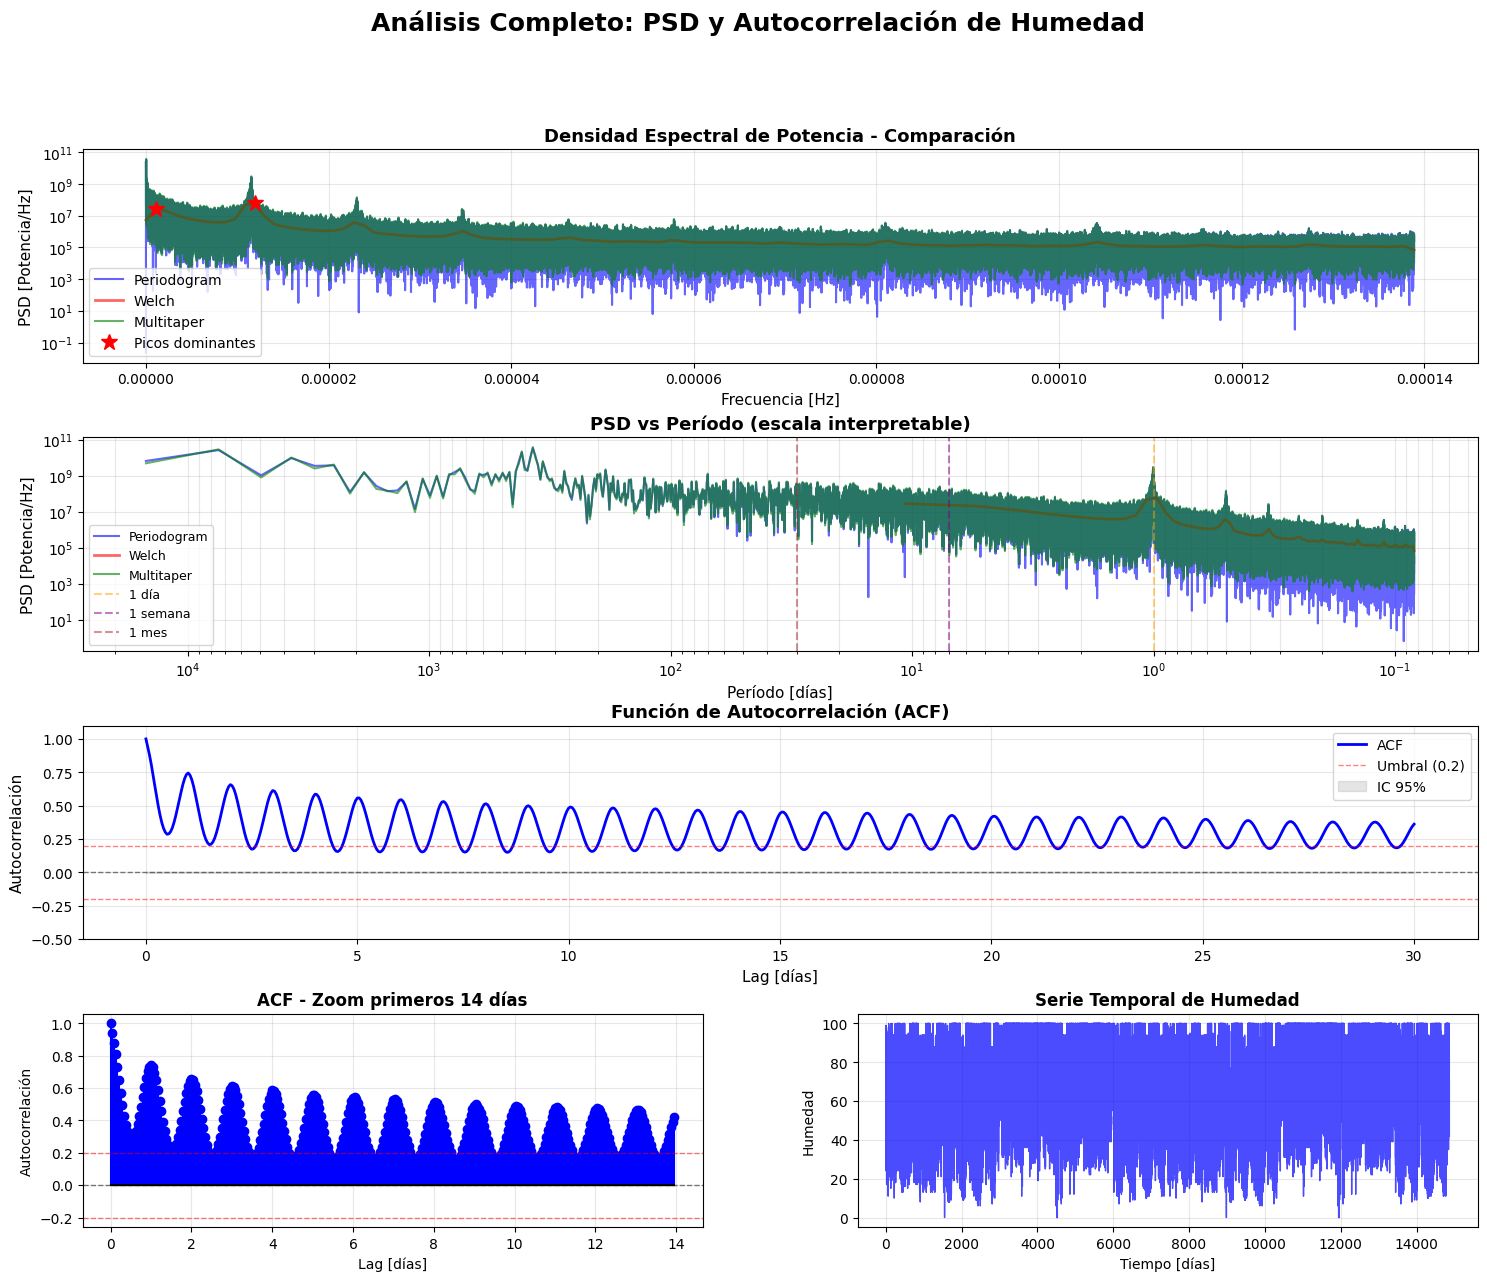


GUARDANDO RESULTADOS...
✓ Autocorrelación guardada en 'autocorrelation_results.csv'

¡Análisis completo finalizado! 🎉


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import welch, periodogram, find_peaks
from scipy.stats import pearsonr

# Asumiendo que ya tienes freq_per, psd_per, freq_welch, psd_welch, freq_multi, psd_multi
# del código anterior y humidity_data

# Convertir a array numpy y eliminar valores NaN
humidity = humidity_data.dropna().values
fs = 1/3600  # Frecuencia de muestreo (datos horarios)

print("="*70)
print("ANÁLISIS DE DENSIDAD ESPECTRAL DE POTENCIA (PSD)")
print("="*70)

# =============================================================================
# ANÁLISIS DE FRECUENCIAS DOMINANTES
# =============================================================================

def analyze_psd(frequencies, psd, method_name, fs):
    """Analiza la PSD para encontrar frecuencias dominantes y patrones"""

    print(f"\n{'─'*70}")
    print(f"📊 ANÁLISIS DEL MÉTODO: {method_name}")
    print(f"{'─'*70}")

    # Encontrar picos significativos
    # Usar prominencia relativa para detectar picos importantes
    prominence = np.max(psd) * 0.1  # Picos con al menos 10% de la potencia máxima
    peaks, properties = find_peaks(psd, prominence=prominence, distance=5)

    if len(peaks) > 0:
        # Ordenar picos por potencia (de mayor a menor)
        sorted_indices = np.argsort(psd[peaks])[::-1]
        top_peaks = peaks[sorted_indices[:5]]  # Top 5 picos

        print(f"\n🔝 Top 5 Frecuencias Dominantes:")
        print(f"{'─'*70}")

        for i, peak_idx in enumerate(top_peaks, 1):
            freq_hz = frequencies[peak_idx]
            power = psd[peak_idx]

            # Convertir frecuencia a períodos interpretables
            if freq_hz > 0:
                period_hours = 1 / (freq_hz * 3600)  # Período en horas
                period_days = period_hours / 24

                print(f"\n  {i}. Frecuencia: {freq_hz:.8f} Hz")
                print(f"     Potencia: {power:.4e}")
                print(f"     Período: {period_hours:.2f} horas ({period_days:.2f} días)")

                # Interpretación del período
                if 23 <= period_hours <= 25:
                    print(f"     💡 Interpretación: Ciclo DIARIO (24h)")
                elif 6 <= period_hours <= 8:
                    print(f"     💡 Interpretación: Ciclo de 12 horas")
                elif 160 <= period_hours <= 190:
                    print(f"     💡 Interpretación: Ciclo SEMANAL (~7 días)")
                elif period_days >= 28 and period_days <= 32:
                    print(f"     💡 Interpretación: Ciclo MENSUAL")
                elif period_days >= 85 and period_days <= 95:
                    print(f"     💡 Interpretación: Ciclo ESTACIONAL (3 meses)")
    else:
        print("\n⚠️  No se detectaron picos significativos en este método")

    # Estadísticas generales
    print(f"\n📈 Estadísticas Generales:")
    print(f"{'─'*70}")
    print(f"  Potencia total: {np.sum(psd):.4e}")
    print(f"  Potencia promedio: {np.mean(psd):.4e}")
    print(f"  Potencia máxima: {np.max(psd):.4e}")
    print(f"  Desviación estándar: {np.std(psd):.4e}")

    return peaks, properties

# Analizar cada método
print("\n" + "="*70)
print("IDENTIFICACIÓN DE PATRONES Y CICLOS EN LA HUMEDAD")
print("="*70)

peaks_per, props_per = analyze_psd(freq_per, psd_per, "PERIODOGRAM", fs)
peaks_welch, props_welch = analyze_psd(freq_welch, psd_welch, "WELCH", fs)
peaks_multi, props_multi = analyze_psd(freq_multi, psd_multi, "MULTITAPER", fs)

# =============================================================================
# FUNCIÓN DE AUTOCORRELACIÓN
# =============================================================================

print("\n\n" + "="*70)
print("FUNCIÓN DE AUTOCORRELACIÓN (ACF)")
print("="*70)

def calculate_acf(data, max_lag=None):
    """Calcula la función de autocorrelación"""

    n = len(data)
    if max_lag is None:
        max_lag = n // 2  # Por defecto, hasta la mitad de los datos

    # Normalizar los datos (restar la media)
    data_normalized = data - np.mean(data)

    # Calcular autocorrelación
    acf = np.correlate(data_normalized, data_normalized, mode='full')
    acf = acf[n-1:]  # Tomar solo la parte positiva

    # Normalizar por la varianza y el número de observaciones
    acf = acf[:max_lag+1] / (np.var(data) * np.arange(n, n-max_lag-1, -1))

    return acf

# Calcular ACF para diferentes lags
max_lag = min(720, len(humidity) // 4)  # Máximo 720 horas (30 días) o 1/4 de los datos
acf_values = calculate_acf(humidity, max_lag)
lags = np.arange(len(acf_values))

print(f"\n📊 Parámetros de ACF:")
print(f"{'─'*70}")
print(f"  Máximo lag analizado: {max_lag} horas ({max_lag/24:.1f} días)")
print(f"  Total de puntos calculados: {len(acf_values)}")

# Encontrar lags significativos (donde ACF > umbral)
threshold = 0.2  # Correlación significativa > 0.2
significant_lags = np.where(acf_values[1:] > threshold)[0] + 1  # Excluir lag 0

print(f"\n🔍 Lags con Correlación Significativa (ACF > {threshold}):")
print(f"{'─'*70}")

if len(significant_lags) > 0:
    # Mostrar los primeros lags significativos
    for i, lag in enumerate(significant_lags[:10], 1):
        acf_val = acf_values[lag]
        lag_hours = lag
        lag_days = lag / 24

        print(f"\n  {i}. Lag: {lag} horas ({lag_days:.2f} días)")
        print(f"     ACF: {acf_val:.4f}")

        # Interpretación
        if 23 <= lag_hours <= 25:
            print(f"     💡 Correlación DIARIA fuerte")
        elif 47 <= lag_hours <= 49:
            print(f"     💡 Correlación cada 2 DÍAS")
        elif 167 <= lag_hours <= 169:
            print(f"     💡 Correlación SEMANAL")
else:
    print("  ⚠️  No se encontraron lags con correlación significativa")

# Encontrar el primer cruce por cero (decorrelación)
zero_crossings = np.where(np.diff(np.sign(acf_values)))[0]
if len(zero_crossings) > 0:
    first_zero = zero_crossings[0]
    print(f"\n⏱️  Primer cruce por cero (decorrelación): {first_zero} horas ({first_zero/24:.2f} días)")
else:
    print(f"\n⏱️  No se detectó cruce por cero en el rango analizado")

# Estadísticas de ACF
print(f"\n📈 Estadísticas de ACF:")
print(f"{'─'*70}")
print(f"  ACF máxima (lag=0): {acf_values[0]:.4f}")
print(f"  ACF mínima: {np.min(acf_values):.4f} (lag={np.argmin(acf_values)} horas)")
print(f"  ACF promedio: {np.mean(acf_values):.4f}")

# =============================================================================
# VISUALIZACIÓN
# =============================================================================

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.25)

fig.suptitle('Análisis Completo: PSD y Autocorrelación de Humedad',
             fontsize=18, fontweight='bold', y=0.98)

# --- GRÁFICA 1: PSD Comparativa con picos marcados ---
ax1 = fig.add_subplot(gs[0, :])
ax1.semilogy(freq_per, psd_per, 'b-', alpha=0.6, label='Periodogram', linewidth=1.5)
ax1.semilogy(freq_welch, psd_welch, 'r-', alpha=0.6, label='Welch', linewidth=2)
ax1.semilogy(freq_multi, psd_multi, 'g-', alpha=0.6, label='Multitaper', linewidth=1.5)

# Marcar picos en Welch (método más suave)
if len(peaks_welch) > 0:
    ax1.plot(freq_welch[peaks_welch], psd_welch[peaks_welch], 'r*',
             markersize=12, label='Picos dominantes', zorder=5)

ax1.set_title('Densidad Espectral de Potencia - Comparación', fontsize=13, fontweight='bold')
ax1.set_xlabel('Frecuencia [Hz]', fontsize=11)
ax1.set_ylabel('PSD [Potencia/Hz]', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# --- GRÁFICA 2: PSD en escala de período (más interpretable) ---
ax2 = fig.add_subplot(gs[1, :])

# Convertir frecuencias a períodos en días
periods_per = 1 / (freq_per[1:] * 3600 * 24)  # Excluir freq=0
periods_welch = 1 / (freq_welch[1:] * 3600 * 24)
periods_multi = 1 / (freq_multi[1:] * 3600 * 24)

ax2.loglog(periods_per, psd_per[1:], 'b-', alpha=0.6, label='Periodogram', linewidth=1.5)
ax2.loglog(periods_welch, psd_welch[1:], 'r-', alpha=0.6, label='Welch', linewidth=2)
ax2.loglog(periods_multi, psd_multi[1:], 'g-', alpha=0.6, label='Multitaper', linewidth=1.5)

# Líneas de referencia para períodos comunes
ax2.axvline(1, color='orange', linestyle='--', alpha=0.5, label='1 día')
ax2.axvline(7, color='purple', linestyle='--', alpha=0.5, label='1 semana')
ax2.axvline(30, color='brown', linestyle='--', alpha=0.5, label='1 mes')

ax2.set_title('PSD vs Período (escala interpretable)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Período [días]', fontsize=11)
ax2.set_ylabel('PSD [Potencia/Hz]', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, which='both')
ax2.invert_xaxis()  # Invertir para que períodos cortos estén a la derecha

# --- GRÁFICA 3: Función de Autocorrelación (completa) ---
ax3 = fig.add_subplot(gs[2, :])
ax3.plot(lags / 24, acf_values, 'b-', linewidth=2, label='ACF')
ax3.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax3.axhline(threshold, color='r', linestyle='--', linewidth=1, alpha=0.5, label=f'Umbral ({threshold})')
ax3.axhline(-threshold, color='r', linestyle='--', linewidth=1, alpha=0.5)

# Sombrear área de confianza del 95%
confidence_interval = 1.96 / np.sqrt(len(humidity))
ax3.fill_between(lags / 24, -confidence_interval, confidence_interval,
                  alpha=0.2, color='gray', label='IC 95%')

ax3.set_title('Función de Autocorrelación (ACF)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Lag [días]', fontsize=11)
ax3.set_ylabel('Autocorrelación', fontsize=11)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([-0.5, 1.1])

# --- GRÁFICA 4: ACF Zoom (primeros días) ---
ax4 = fig.add_subplot(gs[3, 0])
zoom_days = min(14, max_lag // 24)  # Primeros 14 días o menos
zoom_lags = int(zoom_days * 24)

ax4.stem(lags[:zoom_lags] / 24, acf_values[:zoom_lags], linefmt='b-',
         markerfmt='bo', basefmt='k-', label='ACF')
ax4.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax4.axhline(threshold, color='r', linestyle='--', linewidth=1, alpha=0.5)
ax4.axhline(-threshold, color='r', linestyle='--', linewidth=1, alpha=0.5)
ax4.fill_between(lags[:zoom_lags] / 24, -confidence_interval, confidence_interval,
                  alpha=0.2, color='gray')

ax4.set_title(f'ACF - Zoom primeros {zoom_days} días', fontsize=12, fontweight='bold')
ax4.set_xlabel('Lag [días]', fontsize=10)
ax4.set_ylabel('Autocorrelación', fontsize=10)
ax4.grid(True, alpha=0.3)

# --- GRÁFICA 5: Serie temporal de humedad ---
ax5 = fig.add_subplot(gs[3, 1])
time_hours = np.arange(len(humidity))
ax5.plot(time_hours / 24, humidity, 'b-', linewidth=1, alpha=0.7)
ax5.set_title('Serie Temporal de Humedad', fontsize=12, fontweight='bold')
ax5.set_xlabel('Tiempo [días]', fontsize=10)
ax5.set_ylabel('Humedad', fontsize=10)
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('psd_acf_complete_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# GUARDAR RESULTADOS DE ACF
# =============================================================================

print("\n" + "="*70)
print("GUARDANDO RESULTADOS...")
print("="*70)

acf_df = pd.DataFrame({
    'Lag_hours': lags,
    'Lag_days': lags / 24,
    'ACF': acf_values
})
acf_df.to_csv('autocorrelation_results.csv', index=False)
print("✓ Autocorrelación guardada en 'autocorrelation_results.csv'")

print("\n¡Análisis completo finalizado! 🎉")

#Welch con diferentes tamaños de ventana (512, 1024, 2048, 4096) midiendo rendimiento y recursos.

#Ventanas evaluadas: 512, 1024, 2048, 4096
#obtenemos:
- PSD individual de cada tamaño de ventana
- Comparación visual de todas las PSD juntas
- Métricas de rendimiento: tiempo, memoria, CPU
- Análisis adicional: número de segmentos, resolución espectral
- Gráficas de barras y tendencias para cada métrica
- 3 archivos generados:
#importante:

- Ventanas más grandes = mejor resolución espectral pero más tiempo
- Ventanas más pequeñas = más rápido pero menos detalle

Total de muestras: 356793
Frecuencia de muestreo: 0.0002777777777777778 Hz (datos horarios)

EJECUTANDO MÉTODO WELCH CON DIFERENTES TAMAÑOS DE VENTANA

VENTANA: 512 puntos
⏱️  Tiempo de ejecución: 0.425836 segundos
💾 Memoria actual: 0.0185 MB
📊 Memoria pico: 10.9394 MB
🖥️  CPU promedio: 5.00%
📈 Frecuencias calculadas: 257
🔢 Número de segmentos: 1392
⚡ Potencia máxima: 1.2159e+08

VENTANA: 1024 puntos
⏱️  Tiempo de ejecución: 0.155452 segundos
💾 Memoria actual: 0.0146 MB
📊 Memoria pico: 10.9006 MB
🖥️  CPU promedio: 0.00%
📈 Frecuencias calculadas: 513
🔢 Número de segmentos: 695
⚡ Potencia máxima: 1.7772e+08

VENTANA: 2048 puntos
⏱️  Tiempo de ejecución: 0.077205 segundos
💾 Memoria actual: 0.0261 MB
📊 Memoria pico: 10.8894 MB
🖥️  CPU promedio: 0.00%
📈 Frecuencias calculadas: 1025
🔢 Número de segmentos: 347
⚡ Potencia máxima: 3.4787e+08

VENTANA: 4096 puntos
⏱️  Tiempo de ejecución: 0.056931 segundos
💾 Memoria actual: 0.0493 MB
📊 Memoria pico: 10.8841 MB
🖥️  CPU promedio: 4.95%
📈 Frecuenci

/tmp/ipython-input-1192665159.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipython-input-1192665159.py:294: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.savefig('welch_window_comparison.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-1192665159.py:294: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  plt.savefig('welch_window_comparison.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-1192665159.py:294: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  plt.savefig('welch_window_comparison.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-1192665159.py:294: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('welch_window_comparison.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-1192665159.py:294: UserWarning:

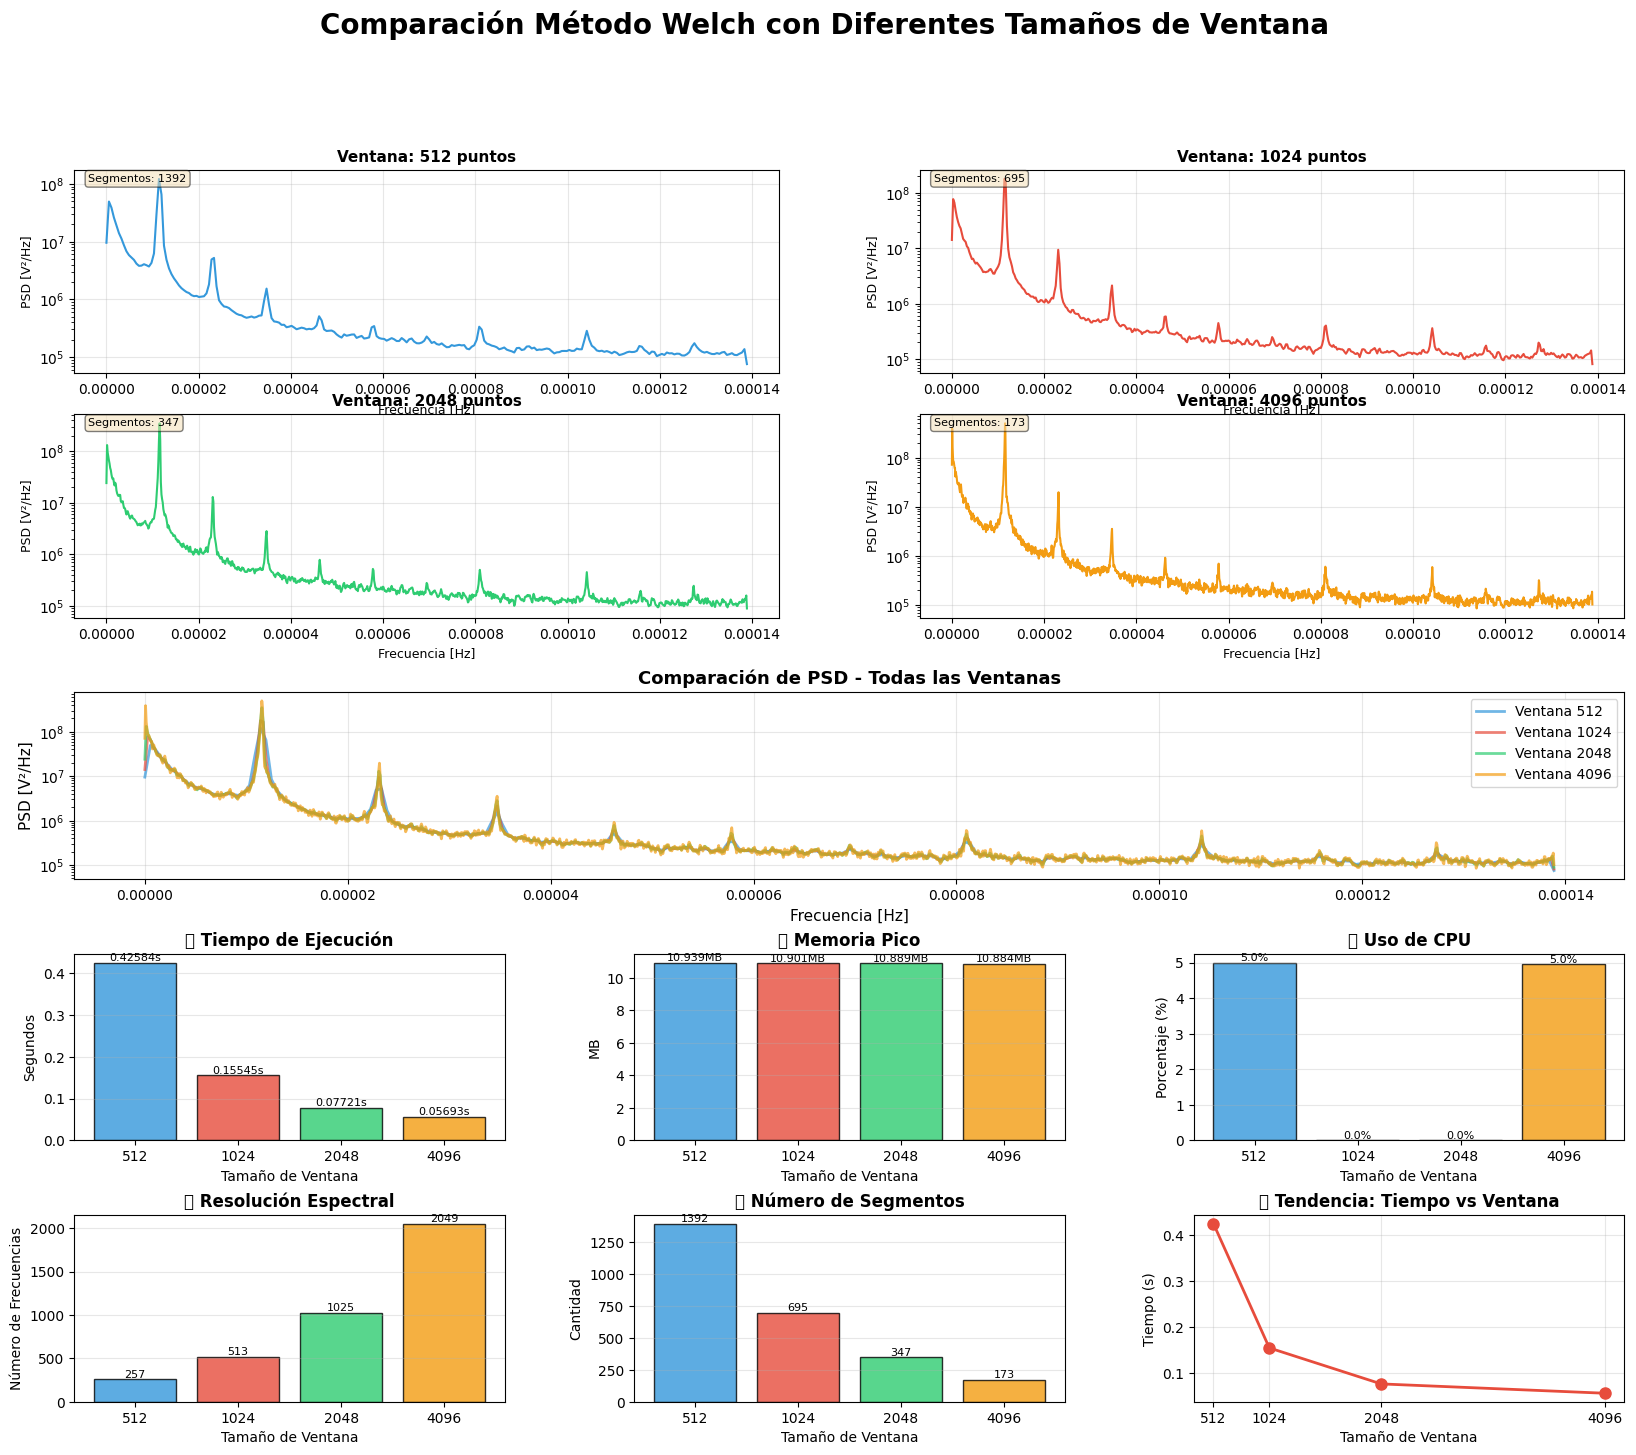


GUARDANDO RESULTADOS...
✓ Métricas guardadas en 'welch_window_metrics.csv'
✓ Resultados PSD guardados en 'welch_psd_all_windows.csv'

¡Análisis completado exitosamente! 🎉

📊 Resumen:
   - Ventanas evaluadas: 4
   - Mejor rendimiento (velocidad): Ventana 4096
   - Mejor resolución espectral: Ventana 4096


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import time
import tracemalloc
import psutil
import os

# Ya tienes tus datos de humedad cargados
# humidity_data = df['humidity']

# Convertir a array numpy y eliminar valores NaN
humidity = humidity_data.dropna().values

# Frecuencia de muestreo (datos horarios)
fs = 1/3600  # Hz

print(f"Total de muestras: {len(humidity)}")
print(f"Frecuencia de muestreo: {fs} Hz (datos horarios)\n")

# Tamaños de ventana a evaluar
window_sizes = [512, 1024, 2048, 4096]

# Verificar que los tamaños de ventana sean válidos
valid_window_sizes = [w for w in window_sizes if w < len(humidity)]
if len(valid_window_sizes) < len(window_sizes):
    print(f"⚠️ Advertencia: Algunos tamaños de ventana son muy grandes para tu dataset")
    print(f"   Tamaños válidos: {valid_window_sizes}\n")
    window_sizes = valid_window_sizes

# Diccionarios para almacenar resultados
psd_results = {}
metrics = {
    'Tamaño Ventana': [],
    'Tiempo (segundos)': [],
    'Memoria Pico (MB)': [],
    'Memoria Usada (MB)': [],
    'CPU (%)': [],
    'Num Frecuencias': [],
    'Num Segmentos': []
}

# Función para medir rendimiento
def measure_welch_performance(data, fs, nperseg):
    """Ejecuta Welch y mide recursos"""

    # Obtener proceso actual
    process = psutil.Process(os.getpid())

    # Iniciar medición de memoria
    tracemalloc.start()

    # CPU inicial
    cpu_percent_start = process.cpu_percent(interval=0.1)

    # Medir tiempo de ejecución
    start_time = time.time()

    # EJECUTAR WELCH
    freq, psd = welch(data, fs=fs, nperseg=nperseg,
                      window='hann', scaling='density')

    end_time = time.time()

    # CPU final
    cpu_percent_end = process.cpu_percent(interval=0.1)
    cpu_avg = (cpu_percent_start + cpu_percent_end) / 2

    # Memoria utilizada
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Calcular métricas
    execution_time = end_time - start_time
    memory_current_mb = current / 1024 / 1024
    memory_peak_mb = peak / 1024 / 1024

    # Calcular número de segmentos
    noverlap = nperseg // 2
    step = nperseg - noverlap
    num_segments = (len(data) - noverlap) // step

    return {
        'freq': freq,
        'psd': psd,
        'time': execution_time,
        'memory_current': memory_current_mb,
        'memory_peak': memory_peak_mb,
        'cpu': cpu_avg,
        'num_freqs': len(freq),
        'num_segments': num_segments
    }

# =============================================================================
# EJECUTAR WELCH CON DIFERENTES TAMAÑOS DE VENTANA
# =============================================================================
print("="*70)
print("EJECUTANDO MÉTODO WELCH CON DIFERENTES TAMAÑOS DE VENTANA")
print("="*70)

for window_size in window_sizes:
    print(f"\n{'='*70}")
    print(f"VENTANA: {window_size} puntos")
    print(f"{'='*70}")

    result = measure_welch_performance(humidity, fs, window_size)

    # Guardar resultados PSD
    psd_results[window_size] = {
        'freq': result['freq'],
        'psd': result['psd']
    }

    # Guardar métricas
    metrics['Tamaño Ventana'].append(window_size)
    metrics['Tiempo (segundos)'].append(result['time'])
    metrics['Memoria Pico (MB)'].append(result['memory_peak'])
    metrics['Memoria Usada (MB)'].append(result['memory_current'])
    metrics['CPU (%)'].append(result['cpu'])
    metrics['Num Frecuencias'].append(result['num_freqs'])
    metrics['Num Segmentos'].append(result['num_segments'])

    # Imprimir resultados
    print(f"⏱️  Tiempo de ejecución: {result['time']:.6f} segundos")
    print(f"💾 Memoria actual: {result['memory_current']:.4f} MB")
    print(f"📊 Memoria pico: {result['memory_peak']:.4f} MB")
    print(f"🖥️  CPU promedio: {result['cpu']:.2f}%")
    print(f"📈 Frecuencias calculadas: {result['num_freqs']}")
    print(f"🔢 Número de segmentos: {result['num_segments']}")
    print(f"⚡ Potencia máxima: {np.max(result['psd']):.4e}")

# =============================================================================
# TABLA COMPARATIVA
# =============================================================================
print("\n" + "="*70)
print("TABLA COMPARATIVA DE RENDIMIENTO")
print("="*70)

metrics_df = pd.DataFrame(metrics)
print(metrics_df.to_string(index=False))

# =============================================================================
# ANÁLISIS COMPARATIVO
# =============================================================================
print("\n" + "="*70)
print("ANÁLISIS COMPARATIVO")
print("="*70)

fastest_idx = metrics_df['Tiempo (segundos)'].idxmin()
slowest_idx = metrics_df['Tiempo (segundos)'].idxmax()

print(f"\n⚡ VELOCIDAD:")
print(f"   Más rápido: Ventana {metrics_df.loc[fastest_idx, 'Tamaño Ventana']} ({metrics_df.loc[fastest_idx, 'Tiempo (segundos)']:.6f}s)")
print(f"   Más lento: Ventana {metrics_df.loc[slowest_idx, 'Tamaño Ventana']} ({metrics_df.loc[slowest_idx, 'Tiempo (segundos)']:.6f}s)")
print(f"   Diferencia: {metrics_df.loc[slowest_idx, 'Tiempo (segundos)'] / metrics_df.loc[fastest_idx, 'Tiempo (segundos)']:.2f}x")

least_mem_idx = metrics_df['Memoria Pico (MB)'].idxmin()
most_mem_idx = metrics_df['Memoria Pico (MB)'].idxmax()

print(f"\n💾 MEMORIA:")
print(f"   Menos memoria: Ventana {metrics_df.loc[least_mem_idx, 'Tamaño Ventana']} ({metrics_df.loc[least_mem_idx, 'Memoria Pico (MB)']:.4f} MB)")
print(f"   Más memoria: Ventana {metrics_df.loc[most_mem_idx, 'Tamaño Ventana']} ({metrics_df.loc[most_mem_idx, 'Memoria Pico (MB)']:.4f} MB)")
print(f"   Diferencia: {metrics_df.loc[most_mem_idx, 'Memoria Pico (MB)'] / metrics_df.loc[least_mem_idx, 'Memoria Pico (MB)']:.2f}x")

print(f"\n📊 RESOLUCIÓN ESPECTRAL:")
print(f"   Mayor resolución (más frecuencias): Ventana {metrics_df.loc[metrics_df['Num Frecuencias'].idxmax(), 'Tamaño Ventana']}")
print(f"   Menor resolución (menos frecuencias): Ventana {metrics_df.loc[metrics_df['Num Frecuencias'].idxmin(), 'Tamaño Ventana']}")

# =============================================================================
# VISUALIZACIÓN COMPLETA
# =============================================================================
# =========================
# BLOQUE DE VISUALIZACIÓN (REEMPLAZAR)
# =========================
fig = plt.figure(figsize=(20, 16))
# Aumentamos a 5 filas para dejar espacio libre (0..4)
gs = fig.add_gridspec(5, 3, hspace=0.40, wspace=0.3)

fig.suptitle('Comparación Método Welch con Diferentes Tamaños de Ventana',
             fontsize=20, fontweight='bold', y=0.98)

colors_psd = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# --- PSD INDIVIDUALES (ocupando filas 0 y 1 del GridSpec, en una subgrilla 2x2) ---
sub_gs = gs[0:2, :].subgridspec(2, 2)  # espacio para 4 subplots (2x2)

for idx, window_size in enumerate(window_sizes):
    ax = fig.add_subplot(sub_gs[idx // 2, idx % 2])
    freq = psd_results[window_size]['freq']
    psd = psd_results[window_size]['psd']

    ax.semilogy(freq, psd, color=colors_psd[idx], linewidth=1.5)
    ax.set_title(f'Ventana: {window_size} puntos', fontsize=11, fontweight='bold')
    ax.set_xlabel('Frecuencia [Hz]', fontsize=9)
    ax.set_ylabel('PSD [V²/Hz]', fontsize=9)
    ax.grid(True, alpha=0.3)

    # Añadir info de segmentos
    num_segs = metrics_df.loc[metrics_df['Tamaño Ventana'] == window_size, 'Num Segmentos'].values[0]
    ax.text(0.02, 0.98, f'Segmentos: {num_segs}',
            transform=ax.transAxes, fontsize=8,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.5))

# --- COMPARACIÓN DE TODAS LAS PSD --- (ahora en la fila 2 completa)
ax_comp = fig.add_subplot(gs[2, :])
for idx, window_size in enumerate(window_sizes):
    freq = psd_results[window_size]['freq']
    psd = psd_results[window_size]['psd']
    ax_comp.semilogy(freq, psd, color=colors_psd[idx],
                     alpha=0.7, label=f'Ventana {window_size}', linewidth=2)

ax_comp.set_title('Comparación de PSD - Todas las Ventanas', fontsize=13, fontweight='bold')
ax_comp.set_xlabel('Frecuencia [Hz]', fontsize=11)
ax_comp.set_ylabel('PSD [V²/Hz]', fontsize=11)
ax_comp.legend(fontsize=10, loc='best')
ax_comp.grid(True, alpha=0.3)

# --- FILA 3: MÉTRICAS (Tiempo, Memoria, CPU) ---
window_labels = [str(w) for w in window_sizes]

ax_time = fig.add_subplot(gs[3, 0])
bars1 = ax_time.bar(window_labels, metrics_df['Tiempo (segundos)'],
                    color=colors_psd[:len(window_sizes)], alpha=0.8, edgecolor='black')
ax_time.set_title('⏱️ Tiempo de Ejecución', fontsize=12, fontweight='bold')
ax_time.set_xlabel('Tamaño de Ventana', fontsize=10)
ax_time.set_ylabel('Segundos', fontsize=10)
ax_time.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    height = bar.get_height()
    ax_time.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.5f}s', ha='center', va='bottom', fontsize=8)

ax_mem = fig.add_subplot(gs[3, 1])
bars2 = ax_mem.bar(window_labels, metrics_df['Memoria Pico (MB)'],
                   color=colors_psd[:len(window_sizes)], alpha=0.8, edgecolor='black')
ax_mem.set_title('💾 Memoria Pico', fontsize=12, fontweight='bold')
ax_mem.set_xlabel('Tamaño de Ventana', fontsize=10)
ax_mem.set_ylabel('MB', fontsize=10)
ax_mem.grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    ax_mem.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}MB', ha='center', va='bottom', fontsize=8)

ax_cpu = fig.add_subplot(gs[3, 2])
bars3 = ax_cpu.bar(window_labels, metrics_df['CPU (%)'],
                   color=colors_psd[:len(window_sizes)], alpha=0.8, edgecolor='black')
ax_cpu.set_title('🖥️ Uso de CPU', fontsize=12, fontweight='bold')
ax_cpu.set_xlabel('Tamaño de Ventana', fontsize=10)
ax_cpu.set_ylabel('Porcentaje (%)', fontsize=10)
ax_cpu.grid(True, alpha=0.3, axis='y')
for bar in bars3:
    height = bar.get_height()
    ax_cpu.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

# --- FILA 4: RESOLUCIÓN, SEGMENTOS y TENDENCIA ---
ax_freqs = fig.add_subplot(gs[4, 0])
bars4 = ax_freqs.bar(window_labels, metrics_df['Num Frecuencias'],
                     color=colors_psd[:len(window_sizes)], alpha=0.8, edgecolor='black')
ax_freqs.set_title('📈 Resolución Espectral', fontsize=12, fontweight='bold')
ax_freqs.set_xlabel('Tamaño de Ventana', fontsize=10)
ax_freqs.set_ylabel('Número de Frecuencias', fontsize=10)
ax_freqs.grid(True, alpha=0.3, axis='y')
for bar in bars4:
    height = bar.get_height()
    ax_freqs.text(bar.get_x() + bar.get_width()/2., height,
                  f'{int(height)}', ha='center', va='bottom', fontsize=8)

ax_segs = fig.add_subplot(gs[4, 1])
bars5 = ax_segs.bar(window_labels, metrics_df['Num Segmentos'],
                    color=colors_psd[:len(window_sizes)], alpha=0.8, edgecolor='black')
ax_segs.set_title('🔢 Número de Segmentos', fontsize=12, fontweight='bold')
ax_segs.set_xlabel('Tamaño de Ventana', fontsize=10)
ax_segs.set_ylabel('Cantidad', fontsize=10)
ax_segs.grid(True, alpha=0.3, axis='y')
for bar in bars5:
    height = bar.get_height()
    ax_segs.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

ax_trend = fig.add_subplot(gs[4, 2])
ax_trend.plot(window_sizes, metrics_df['Tiempo (segundos)'],
              marker='o', linewidth=2, markersize=8, color='#e74c3c')
ax_trend.set_title('📊 Tendencia: Tiempo vs Ventana', fontsize=12, fontweight='bold')
ax_trend.set_xlabel('Tamaño de Ventana', fontsize=10)
ax_trend.set_ylabel('Tiempo (s)', fontsize=10)
ax_trend.grid(True, alpha=0.3)
ax_trend.set_xticks(window_sizes)

plt.tight_layout()
plt.savefig('welch_window_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
# =========================


# =============================================================================
# GUARDAR RESULTADOS
# =============================================================================
print("\n" + "="*70)
print("GUARDANDO RESULTADOS...")
print("="*70)

# Guardar métricas de rendimiento
metrics_df.to_csv('welch_window_metrics.csv', index=False)
print("✓ Métricas guardadas en 'welch_window_metrics.csv'")

# Guardar PSD de cada ventana
max_len = max(len(psd_results[w]['freq']) for w in window_sizes)
psd_export = {}

for window_size in window_sizes:
    freq = psd_results[window_size]['freq']
    psd = psd_results[window_size]['psd']

    psd_export[f'Freq_W{window_size}'] = np.pad(freq, (0, max_len - len(freq)),
                                                  constant_values=np.nan)
    psd_export[f'PSD_W{window_size}'] = np.pad(psd, (0, max_len - len(psd)),
                                                constant_values=np.nan)

psd_df = pd.DataFrame(psd_export)
psd_df.to_csv('welch_psd_all_windows.csv', index=False)
print("✓ Resultados PSD guardados en 'welch_psd_all_windows.csv'")

print("\n" + "="*70)
print("¡Análisis completado exitosamente! 🎉")
print("="*70)
print(f"\n📊 Resumen:")
print(f"   - Ventanas evaluadas: {len(window_sizes)}")
print(f"   - Mejor rendimiento (velocidad): Ventana {metrics_df.loc[fastest_idx, 'Tamaño Ventana']}")
print(f"   - Mejor resolución espectral: Ventana {metrics_df.loc[metrics_df['Num Frecuencias'].idxmax(), 'Tamaño Ventana']}")
#print(f"   - Archivos generados: 3 (CSV x2 + PNG x1)")


--- Test de Gaussianidad para Periodogram ---
Shapiro-Wilk: estadístico=0.9755, p-valor=0.0000
D’Agostino-Pearson: estadístico=11141.4361, p-valor=0.0000
Kolmogorov-Smirnov: estadístico=0.0652, p-valor=0.0000
❌ Se rechaza H0: la distribución NO parece normal.

--- Test de Gaussianidad para Welch ---
Shapiro-Wilk: estadístico=0.7668, p-valor=0.0000
D’Agostino-Pearson: estadístico=49.7070, p-valor=0.0000
Kolmogorov-Smirnov: estadístico=0.2100, p-valor=0.0000
❌ Se rechaza H0: la distribución NO parece normal.

--- Test de Gaussianidad para Multitaper ---
Shapiro-Wilk: estadístico=0.9617, p-valor=0.0000
D’Agostino-Pearson: estadístico=22687.2189, p-valor=0.0000


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 178397.
  res = hypotest_fun_out(*samples, **kwds)


Kolmogorov-Smirnov: estadístico=0.0729, p-valor=0.0000
❌ Se rechaza H0: la distribución NO parece normal.


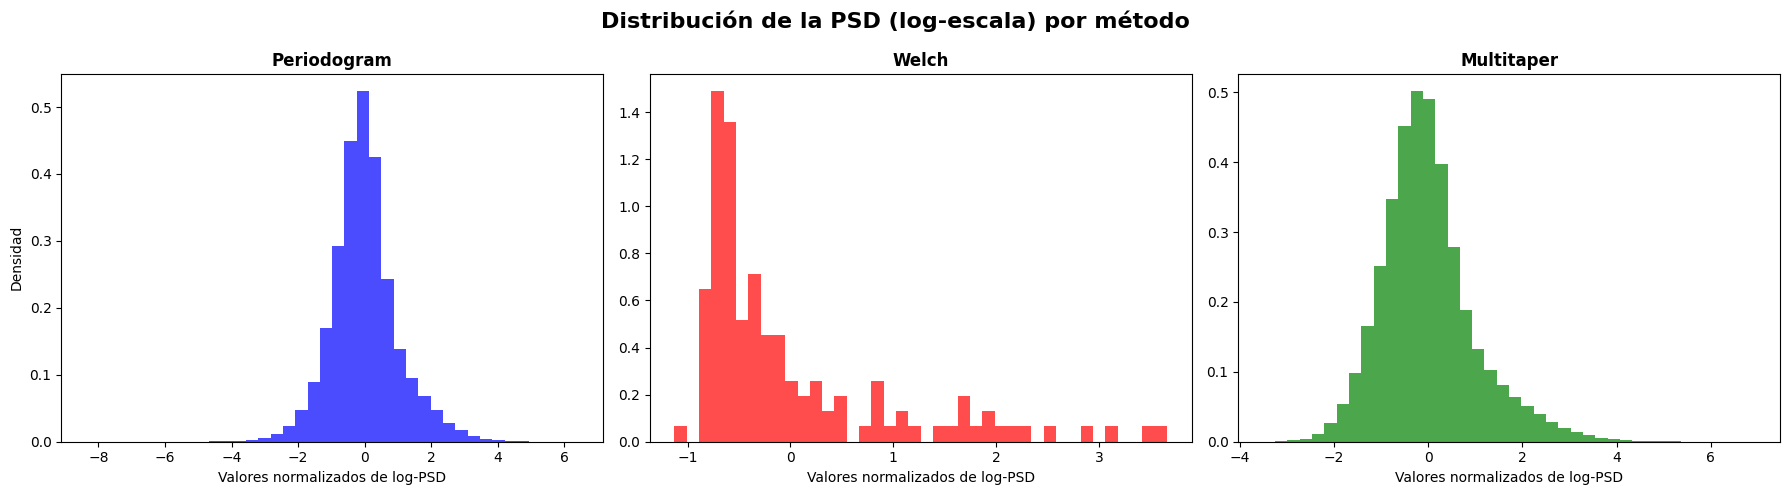

In [38]:
# =============================================================================
# ANÁLISIS DE DISTRIBUCIÓN Y GAUSIANIDAD DE LA PSD
# =============================================================================
from scipy.stats import shapiro, normaltest, kstest, norm

# Función para realizar test de gaussianidad
def gaussianity_tests(psd, label):
    print(f"\n--- Test de Gaussianidad para {label} ---")

    # Filtrar ceros/infinito (que pueden dañar los test estadísticos)
    psd_clean = psd[np.isfinite(psd) & (psd > 0)]

    # Normalizar log-PSD para evitar escalas grandes
    psd_norm = (np.log(psd_clean) - np.mean(np.log(psd_clean))) / np.std(np.log(psd_clean))

    # Test de Shapiro-Wilk
    stat_sw, p_sw = shapiro(psd_norm)
    print(f"Shapiro-Wilk: estadístico={stat_sw:.4f}, p-valor={p_sw:.4f}")

    # Test de D’Agostino-Pearson
    stat_dp, p_dp = normaltest(psd_norm)
    print(f"D’Agostino-Pearson: estadístico={stat_dp:.4f}, p-valor={p_dp:.4f}")

    # Test Kolmogorov-Smirnov
    stat_ks, p_ks = kstest(psd_norm, 'norm')
    print(f"Kolmogorov-Smirnov: estadístico={stat_ks:.4f}, p-valor={p_ks:.4f}")

    # Decisión
    if p_sw > 0.05 and p_dp > 0.05 and p_ks > 0.05:
        print("✅ No se rechaza H0: la distribución puede ser normal (gaussiana).")
    else:
        print("❌ Se rechaza H0: la distribución NO parece normal.")

    return psd_norm

# Histograma de las distribuciones PSD
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribución de la PSD (log-escala) por método", fontsize=16, fontweight='bold')

# Periodogram
psd_per_norm = gaussianity_tests(psd_per, "Periodogram")
axes[0].hist(psd_per_norm, bins=40, color='blue', alpha=0.7, density=True)
axes[0].set_title("Periodogram", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Valores normalizados de log-PSD")
axes[0].set_ylabel("Densidad")

# Welch
psd_welch_norm = gaussianity_tests(psd_welch, "Welch")
axes[1].hist(psd_welch_norm, bins=40, color='red', alpha=0.7, density=True)
axes[1].set_title("Welch", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Valores normalizados de log-PSD")

# Multitaper
psd_multi_norm = gaussianity_tests(psd_multi, "Multitaper")
axes[2].hist(psd_multi_norm, bins=40, color='green', alpha=0.7, density=True)
axes[2].set_title("Multitaper", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Valores normalizados de log-PSD")

plt.tight_layout()
plt.show()
